# MePRAM preprocessing overview

This documented copy outlines how raw MePRAM tables are loaded, harmonised, and merged into modelling-ready datasets, highlighting the intent of each processing stage.

## Environment setup

Import the scientific Python stack, profiling utilities, and Spark placeholders required throughout the preprocessing pipeline.

In [44]:
import sqlite3
from ydata_profiling import ProfileReport
import pandas as pd
import numpy as np
import re
import os
import pyspark

## Run metadata and storage paths

Capture the execution timestamp and configure local folders / SQLite filenames used to persist intermediate outputs.

In [45]:
today = pd.Timestamp("today").strftime("%Y%m%d_%H%M%S")
save_location = "/home/pmata/mepram_data/"
db_filename = "db_mepram_sepsis_vf.sqlite3"

## Helper: code-to-name mapping template

Provide a (commented) Spark utility to translate coded form values into readable labels when Spark-based processing is required.

In [46]:
def codes_to_names(tab_to_process, codes_tab, shortname):
    errors = []
    codes_group = codes_tab.filter(F.col("form") == shortname)
    
    try:
        codes_group = codes_group.withColumn("value", F.col("value").cast("long"))
    except Exception:
        pass
    
    codes_group = codes_group.filter(F.col("value").isNotNull())
    
    if codes_group.count() == 0:
        print("NO VARS TO RENAME IN:", shortname)
        return tab_to_process, errors
    
    variables = [row.variable for row in codes_group.select("variable").distinct().collect()]
    
    for varname in variables:
        if varname == "fenotipo_resist_colo":
            varname = "feno_resist_colo"
        
        vartab = codes_group.filter(F.col("variable") == varname)
        
        mapping_rows = vartab.select("value", "name").collect()
        codes2names_dict = {row["value"]: row["name"] for row in mapping_rows}
        
        print(f"RENAMING {varname} for {codes2names_dict}:")
        
        try:
            mapping_expr = F.create_map([F.lit(x) for kv in codes2names_dict.items() for x in kv])
            
            tab_to_process = tab_to_process.withColumn(
                varname,
                mapping_expr.getItem(F.col(varname).cast("string")).cast("string")
            )
        
        except Exception as e:
            errors.append(
                f"Could not rename {varname}. Columns found: {tab_to_process.columns}. Error: {e}"
            )
            continue
    
    return tab_to_process, errors

"""db_path = os.path.join(save_location, "db_mepram_sepsis_vf.sqlite3")
con = sqlite3.connect(db_path)
tablenames = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table'", con
)

tablenames = sorted([x for x in tablenames][:-1])
tableshort = sorted([x.replace("tbl_", "") for x in tablenames])
print(tableshort)
codes_tab = pd.read_sql_query("SELECT * from tbl_codes2names", con)
codes_tab = codes_tab.drop("recode")
all_tabs = {}
errors = {}
for tabname, shortname in zip(tablenames, tableshort):
    print("tabname:", tabname, "/// shortname:", shortname)
    tab_to_process = pd.read_sql_query(
        f"SELECT * from {tabname}", con, infer_schema_length=None
    )
    all_tabs[tabname], errors[tabname] = codes_to_names(
        tab_to_process, codes_tab, shortname
    )"""

'db_path = os.path.join(save_location, "db_mepram_sepsis_vf.sqlite3")\ncon = sqlite3.connect(db_path)\ntablenames = pd.read_sql_query(\n    "SELECT name FROM sqlite_master WHERE type = \'table\'", con\n)\n\ntablenames = sorted([x for x in tablenames][:-1])\ntableshort = sorted([x.replace("tbl_", "") for x in tablenames])\nprint(tableshort)\ncodes_tab = pd.read_sql_query("SELECT * from tbl_codes2names", con)\ncodes_tab = codes_tab.drop("recode")\nall_tabs = {}\nerrors = {}\nfor tabname, shortname in zip(tablenames, tableshort):\n    print("tabname:", tabname, "/// shortname:", shortname)\n    tab_to_process = pd.read_sql_query(\n        f"SELECT * from {tabname}", con, infer_schema_length=None\n    )\n    all_tabs[tabname], errors[tabname] = codes_to_names(\n        tab_to_process, codes_tab, shortname\n    )'

## Load database tables

Connect to the configured SQLite database and pull every `tbl_*` table into the `dataframes` dictionary for downstream transformations.

In [47]:
import pandas as pd
import numpy as np
import sqlite3
import re
import os
con = sqlite3.connect(os.path.join(save_location, db_filename))

cursor = con.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

"""with open(os.path.join(save_location, "tbl_personid2center.sql"), "r") as f:
    sql_script = f.read()
    cursor.executescript(sql_script)

with open(os.path.join(save_location, "tbl_microorganismos.sql"), "r") as f:
    sql_script = f.read()
    cursor.executescript(sql_script)"""

tables = [row[0] for row in cursor.fetchall()]

print(tables)

dataframes = {}
for table in tables:
    print(f"Cargando la tabla: {table}")
    dataframes[table] = pd.read_sql_query(f"SELECT * FROM {table}", con)
con.close()



['tbl_master', 'tbl_paciente', 'tbl_comorbilidad', 'tbl_factores_riesgo_bmr', 'tbl_sintomas', 'tbl_signos', 'tbl_sepsis', 'tbl_infecciones_previas', 'tbl_colonizaciones_previas', 'tbl_tratamiento_antibiotico_previo', 'tbl_tratamiento_empirico', 'tbl_hemocultivo_de_urgencias', 'tbl_otros_cultivos_en_urgencias', 'tbl_codes2names', 'tbl_personid2center', 'tbl_microorganismos']
Cargando la tabla: tbl_master
Cargando la tabla: tbl_paciente
Cargando la tabla: tbl_comorbilidad
Cargando la tabla: tbl_factores_riesgo_bmr
Cargando la tabla: tbl_sintomas
Cargando la tabla: tbl_signos
Cargando la tabla: tbl_sepsis
Cargando la tabla: tbl_infecciones_previas
Cargando la tabla: tbl_colonizaciones_previas
Cargando la tabla: tbl_tratamiento_antibiotico_previo
Cargando la tabla: tbl_tratamiento_empirico
Cargando la tabla: tbl_hemocultivo_de_urgencias
Cargando la tabla: tbl_otros_cultivos_en_urgencias
Cargando la tabla: tbl_codes2names
Cargando la tabla: tbl_personid2center
Cargando la tabla: tbl_microor

In [48]:
import re
for name, table in dataframes.items():
    print(name.replace("tbl", "formulario"))
    print("Columnas: ", re.sub(r"[\[\]]", "", str([x for x  in table.columns])))


formulario_master
Columnas:  'person_id', 'fecha_ingreso_urgencias', 'valido', 'record_id'
formulario_paciente
Columnas:  'person_id', 'fecha_ingreso_urgencias', 'fecha_nacimiento', 'edad', 'sexo', 'codigo_postal', 'mujer_gestante', 'mayor_65', 'paciente_residencia'
formulario_comorbilidad
Columnas:  'person_id', 'fecha_ingreso_urgencias', 'infarto', 'insuficiencia_cardiaca', 'evp', 'e_cerebrovascular', 'demencia', 'e_pulmonar_cronica', 'ulcera_peptica', 'colagenopatia', 'hemiplejia', 'erc', 'neoplasia', 'tipo_cancer', 'linfoma', 'leucemia', 'sida', 'hepatopatia', 'tipo_hepatopatia', 'diabetes', 'indice_de_charlson', 'inmunosupresion', 'causa_inmunosupresion', 'situacion_funcional_basal'
formulario_factores_riesgo_bmr
Columnas:  'person_id', 'fecha_ingreso_urgencias', 'hospit_ano_previo', 'hospit_mes_previo', 'hospit_ano_previo_uci', 'cirugia_previa_sin_implant', 'cirugia_previa_con_implant', 'asistencia_sanitaria_prev', 'hemodialisis_permanente', 'dialisis_peritoneal', 'cateter_venoso

## Utility: handle outliers and categorise continuous variables

Define `process_variables` to flag IQR-based outliers, replace them with `NaN`, and bucket continuous values into ordinal ranges.

In [49]:
def process_variables(df, variables):
    """
    This function replaces outliers with NaN using IQR and recodes quantitative variables into ranges 0-3.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    variables (list): List of column names to process.

    Returns:
    pd.DataFrame: The DataFrame with outliers replaced by NaN and new recoded columns.
    """

    df_processed = df.copy()
    
    for var in variables:
        if var not in df.columns:
            print(f"Variable '{var}' not found in the DataFrame. It will be skipped.")
            continue

        Q1 = df_processed[var].quantile(0.25)
        Q3 = df_processed[var].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 3 * IQR
        upper_limit = Q3 + 3 * IQR

        outliers_mask = (df_processed[var] < lower_limit) | (df_processed[var] > upper_limit)
        outliers_count = outliers_mask.sum()
        if outliers_count > 0:
            print(f"{outliers_count} outliers replaced with NaN in the variable '{var}'.")
            print(f"{df_processed.loc[outliers_mask, var]}")            

        df_processed.loc[outliers_mask, var] = np.nan

        new_column = f"{var}_recoded"

        df_processed[new_column] = pd.qcut(df_processed[var], 
                                           q=4, 
                                           labels=[0, 1, 2, 3], 
                                           duplicates='drop')

        df_processed[new_column] = df_processed[new_column].astype('Int64') 
        
        print(f"Variable '{var}' recoded in the column '{new_column}'.")
    
    return df_processed

## Patient master record (`tbl_paciente`)

Combine base patient information with centre identifiers and derive flags such as previous infection and resistant organism history.

In [50]:
df_pacientes = dataframes["tbl_paciente"].merge(dataframes["tbl_personid2center"], how="left")

df_pacientes["inf_previa_sino"] = np.where(np.isin(df_pacientes["person_id"].values, dataframes['tbl_infecciones_previas']["person_id"].values) == True, 1, 0)

bmr_previa = dataframes['tbl_infecciones_previas'].groupby("person_id")["bmr_infec_previa"].apply(lambda x: (x > 0).any())

df_pacientes = df_pacientes.merge(bmr_previa, on="person_id", how="left").fillna(False)
df_pacientes["bmr_infec_previa"] = np.where(df_pacientes["bmr_infec_previa"], 1, 0)


/tmp/ipykernel_2766802/3359684473.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_pacientes = df_pacientes.merge(bmr_previa, on="person_id", how="left").fillna(False)


## Comorbidity features (`tbl_comorbilidad`)

One-hot encode cancer and hepatopathy categories to expose chronic-condition indicators for modelling.

In [51]:
tbl_comorbilidad = dataframes['tbl_comorbilidad']
tbl_comorbilidad = pd.get_dummies(tbl_comorbilidad, columns=["tipo_cancer","tipo_hepatopatia"])
print(tbl_comorbilidad)

      person_id fecha_ingreso_urgencias  infarto  insuficiencia_cardiaca  evp  \
0             1              2021-04-22        0                       0    0   
1             2              2021-05-07        0                       0    0   
2             3              2021-06-04        0                       0    0   
3             4              2021-06-22        0                       0    0   
4             5              2021-03-24        0                       0    0   
...         ...                     ...      ...                     ...  ...   
3908       3909              2023-01-18        0                       1    0   
3909       3910              2023-04-23        0                       0    0   
3910       3911              2023-04-10        0                       0    0   
3911       3912              2023-06-19        0                       0    0   
3912       3913              2023-06-26        0                       0    0   

      e_cerebrovascular  de

## BMR risk factor tracker (`tbl_factores_riesgo_bmr`)

Inspect multi-drug resistance risk factors and prepare them for merges without further transformation.

In [52]:
tbl_factores_riesgo_bmr = dataframes['tbl_factores_riesgo_bmr']
print(tbl_factores_riesgo_bmr)

      person_id fecha_ingreso_urgencias  hospit_ano_previo  hospit_mes_previo  \
0             1              2021-04-22                  1                  1   
1             2              2021-05-07                  1                  1   
2             3              2021-06-04                  1                  1   
3             4              2021-06-22                  1                  1   
4             5              2021-03-24                  0                  0   
...         ...                     ...                ...                ...   
3908       3909              2023-01-18                  0                  0   
3909       3910              2023-04-23                  0                  0   
3910       3911              2023-04-10                  1                  1   
3911       3912              2023-06-19                  0                  0   
3912       3913              2023-06-26                  0                  0   

      hospit_ano_previo_uci

## Symptom presentation (`tbl_sintomas`)

- Pivot symptom duration into wide format to accumulate days per symptom.
- Derive presence/absence binaries and categorical duration buckets (0: none, 1: acute ≤7d, 2: prolonged >7d).

In [53]:
tbl_sintomas = dataframes['tbl_sintomas']
tbl_sintomas["sintoma"] = tbl_sintomas["sintoma"].astype(str)
tbl_sintomas["sintoma"] = "sintoma_" + tbl_sintomas["sintoma"]
tbl_sintomas_pivoted = tbl_sintomas.pivot_table(
    index=["person_id", "fecha_ingreso_urgencias"],  
    columns="sintoma",
    values="duracion_sintoma",
    aggfunc="sum",
    fill_value=0).reset_index()

presence_absence= tbl_sintomas_pivoted.copy()
presence_absence.iloc[:, 2:] = (presence_absence.iloc[:, 2:] > 0).astype(int)

recategorized= tbl_sintomas_pivoted.copy()
recategorized.iloc[:, 2:] = recategorized.iloc[:, 2:].applymap(
    lambda x:0 if x== 0 else (1 if x <= 7 else 2)
)

tbl_sintomas_complete = presence_absence.merge(
    recategorized, on= ['person_id', 'fecha_ingreso_urgencias'], suffixes= ("", "_categorico")
)

print(tbl_sintomas_complete)

sintoma  person_id fecha_ingreso_urgencias  sintoma_1.0  sintoma_10.0  \
0                1              2021-04-22          1.0           0.0   
1                2              2021-05-07          1.0           0.0   
2                3              2021-06-04          1.0           0.0   
3                4              2021-06-22          1.0           0.0   
4                5              2021-03-24          1.0           0.0   
...            ...                     ...          ...           ...   
3908          3909              2023-01-18          1.0           1.0   
3909          3910              2023-04-23          1.0           0.0   
3910          3911              2023-04-10          1.0           0.0   
3911          3912              2023-06-19          1.0           0.0   
3912          3913              2023-06-26          1.0           0.0   

sintoma  sintoma_11.0  sintoma_12.0  sintoma_13.0  sintoma_14.0  sintoma_15.0  \
0                 0.0           0.0       

/tmp/ipykernel_2766802/2736102941.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  recategorized.iloc[:, 2:] = recategorized.iloc[:, 2:].applymap(


## Vital sign measurements (`tbl_signos`)

Parse numeric readings, normalise units, and derive clinical flags (hypotension, tachypnea, tachycardia, hypoxemia).

In [54]:
tbl_signos = dataframes['tbl_signos']

for col in tbl_signos.columns[2:]:
    tbl_signos[col] = tbl_signos[col].apply(lambda x: re.findall(r'\d+\.\d+|\d+', str(x)))
    tbl_signos[col] = tbl_signos[col].apply(lambda x: float(x[0]) if x else None)
    
tbl_signos['hipotermia_hipertermia'] = np.where(tbl_signos['temperatura'] >= 38, 2,
                                np.where(tbl_signos['temperatura'] >= 36, 0, 1))
tbl_signos['hipotermia_hipertermia'] = tbl_signos['hipotermia_hipertermia'].where(tbl_signos['temperatura'].notna())

#tbl_signos = tbl_signos.drop(columns=['hipotermia_hipertermia'])
tbl_signos['hipotension'] = np.where(tbl_signos['tension_arterial'].isna(), tbl_signos['hipotension'],
                                     np.where(tbl_signos['tension_arterial'] <= 100, 1, 0))
tbl_signos['taquipnea'] = np.where(tbl_signos['frec_respiratoria'].isna(), tbl_signos['taquipnea'],
                                   np.where(tbl_signos['frec_respiratoria'] > 20, 1, 0))
tbl_signos['taquicardia'] = np.where(tbl_signos['frec_cardiaca'].isna(), tbl_signos['taquicardia'],
                                     np.where(tbl_signos['frec_cardiaca'] >90, 1, 0))
tbl_signos['hipoxemia'] = np.where(tbl_signos['saturacion_o2'].isna(), tbl_signos['hipoxemia'],
                                     np.where(tbl_signos['saturacion_o2'] >90, 0, 1))
print(tbl_signos)

      person_id fecha_ingreso_urgencias  temperatura  hipotermia_hipertermia  \
0             1              2021-04-22         37.2                       0   
1             2              2021-05-07         37.0                       0   
2             3              2021-06-04         37.9                       0   
3             4              2021-06-22         37.8                       0   
4             5              2021-03-24         39.0                       2   
...         ...                     ...          ...                     ...   
3908       3909              2023-01-18         38.0                       2   
3909       3910              2023-04-23         37.6                       0   
3910       3911              2023-04-10         37.8                       0   
3911       3912              2023-06-19         38.0                       2   
3912       3913              2023-06-26         37.6                       0   

      frec_cardiaca  taquicardia  frec_

## Apply IQR-based cleaning to vital sign variables

Use the helper to remove extreme values from key vital sign metrics before merging them into the main dataset.

In [55]:
vairables= ['temperatura', 'frec_respiratoria', 'frec_cardiaca', 'tension_arterial','saturacion_o2']
tbl_signos = process_variables(tbl_signos, vairables)

Variable 'temperatura' recoded in the column 'temperatura_recoded'.
9 outliers replaced with NaN in the variable 'frec_respiratoria'.
293     46.0
553     50.0
2325    48.0
2400    50.0
2442    52.0
2481    52.0
3433    47.0
3461    51.0
3477    52.0
Name: frec_respiratoria, dtype: float64
Variable 'frec_respiratoria' recoded in the column 'frec_respiratoria_recoded'.
Variable 'frec_cardiaca' recoded in the column 'frec_cardiaca_recoded'.
Variable 'tension_arterial' recoded in the column 'tension_arterial_recoded'.
70 outliers replaced with NaN in the variable 'saturacion_o2'.
385     75.0
401     80.0
617     78.0
620     75.0
638     80.0
        ... 
3652    70.0
3660    70.0
3670    75.0
3810    70.0
3818    70.0
Name: saturacion_o2, Length: 70, dtype: float64
Variable 'saturacion_o2' recoded in the column 'saturacion_o2_recoded'.


## Sepsis assessment (`tbl_sepsis`)

Numerically encode sepsis questionnaire responses (e.g., lactate) and run the outlier-handling helper on selected labs.

In [56]:
tbl_sepsis = dataframes['tbl_sepsis']
tbl_sepsis['lactato_serico'] = np.where(tbl_sepsis['lactato_serico'] == '<= 2 millimole per liter', 0, 1)
for col in tbl_sepsis.columns[2:]:
    tbl_sepsis[col] = tbl_sepsis[col].apply(lambda x: re.findall(r'\d+\.\d+|\d+', str(x)))
    tbl_sepsis[col] = tbl_sepsis[col].apply(lambda x: float(x[0]) if len(x) > 0 else None)
print(tbl_sepsis)

# Remove outliers and recode

variables =['proteina_c_reactiva']
tbl_sepsis = process_variables(tbl_sepsis, variables)

      person_id fecha_ingreso_urgencias  foco  sepsis  shock_septico  sofa  \
0             1              2021-04-22   1.0     1.0            0.0   6.0   
1             2              2021-05-07   8.0     0.0            0.0   4.0   
2             3              2021-06-04  12.0     0.0            0.0   5.0   
3             4              2021-06-22  12.0     1.0            0.0   6.0   
4             5              2021-03-24   1.0     0.0            0.0   4.0   
...         ...                     ...   ...     ...            ...   ...   
3908       3909              2023-01-18   4.0     0.0            0.0   1.0   
3909       3910              2023-04-23   3.0     1.0            0.0   2.0   
3910       3911              2023-04-10   4.0     1.0            0.0   3.0   
3911       3912              2023-06-19   2.0     1.0            0.0   2.0   
3912       3913              2023-06-26   4.0     0.0            0.0   1.0   

      respiracion  snc_glasgow  cardiovascular  bilirrubina  pl

## Previous infection history (`tbl_infecciones_previas`)

- Map microorganism SNOMED codes to clinical categories and pivot them into dummy features.
- Count infection events per patient and compute inter-event timing statistics.

In [57]:
# Load table with classification group for each organism in column label
organism_classification = dataframes["tbl_microorganismos"].copy()

# Rename default values for final classification, use _ to separate target variables
label_map = {
    "NOEB": "_Other bacteria",
    "VIRUS": "_Virus",
    "FUNGUS": "_Fungi",
    "OEB": "_Enterobacteria",
    "ECOLI": "Escherichia coli",
    "SA": "Staphylococcus aureus",
    "PSA": "Pseudomonas aeruginosa",
    "KP": "Klebsiella pneumoniae",
    "SP": "Streptococcus pneumoniae",
    "EC": "Enterococcus"
}
organism_classification["label"] = organism_classification["label"].map(label_map)
# organism_classification[organism_classification.duplicated(subset="snomed_code", keep=False)].sort_values(by=["snomed_code", "label"])
# There are snomed_codes with 2 labels, so always keep the most informative
organism_classification = organism_classification.sort_values(by=["snomed_code", "label"]).drop_duplicates(subset="snomed_code", keep="first")
# Create a dictionary with {organism-snomed-code (value) : classification group (label)}
organism_codes_map = dict(zip(organism_classification["snomed_code"], organism_classification["label"])) #label
print(organism_codes_map)

{'10021006': '_Enterobacteria', '10049004': '_Other bacteria', '10091000087105': '_Other bacteria', '10151000087104': '_Fungi', '1017006': '_Other bacteria', '10171000087105': '_Fungi', '10210008': '_Fungi', '10262005': 'Enterococcus', '10334001': '_Enterobacteria', '103427005': '_Other bacteria', '103428000': '_Other bacteria', '103429008': 'Escherichia coli', '103434007': '_Enterobacteria', '103435008': '_Enterobacteria', '103436009': 'Enterococcus', '103437000': 'Enterococcus', '103438005': 'Enterococcus', '103447002': '_Other bacteria', '103448007': '_Other bacteria', '103449004': '_Other bacteria', '103450004': '_Other bacteria', '103452007': '_Other bacteria', '103453002': '_Other bacteria', '103454008': '_Other bacteria', '103455009': '_Other bacteria', '103459003': '_Other bacteria', '103460008': '_Other bacteria', '103461007': '_Other bacteria', '103462000': '_Other bacteria', '103474001': '_Other bacteria', '103475000': '_Other bacteria', '103476004': '_Other bacteria', '1034

In [58]:
tbl_infecciones_previas_mer = dataframes['tbl_infecciones_previas'].copy()


# Pasamos a dummy los microorganismos y rellenamos la información con el sumatorio de cada dummy. De este modo no perdemos información.
# Finalmente lo almacenamos en tbl_infecciones_previas_microorganismo
tbl_infecciones_previas_mer['grupo_microorganismo'] = tbl_infecciones_previas_mer['microorganism_infec_prev'].astype(str).map(organism_codes_map)
tbl_infecciones_previas_mer = tbl_infecciones_previas_mer.drop(columns=['microorganism_infec_prev', 'bmr_infec_previa', 'feno_resist_infec_prev'])
tbl_infecciones_previas_mer["dummy"] = 1
#tbl_infecciones_previas_mer = pd.get_dummies(tbl_infecciones_previas_mer, columns=['feno_resist_infec_prev'])
tbl_infecciones_previas_microorganismos = tbl_infecciones_previas_mer.pivot_table(
    index=["person_id", "fecha_ingreso_urgencias"],  
    columns="grupo_microorganismo",
    values="dummy",
    aggfunc="sum",
    fill_value=0).reset_index()

## Hemoculture results from the emergency department

Deep-copy the hemoculture table, map microorganism codes to organism groups, and inject clinician-reviewed co-infection resolutions for the target label.

In [59]:
import copy
hemo_urg = copy.deepcopy(dataframes['tbl_hemocultivo_de_urgencias'])
hemo_urg["microorganismo"] = hemo_urg["microorganismo"].fillna("0").astype(int).astype(str).map(lambda x: organism_codes_map.get(x, "NEGATIVE"))
hemo_urg["microorganismo"].value_counts()

microorganismo
NEGATIVE                    2074
Escherichia coli            1420
Klebsiella pneumoniae        504
_Enterobacteria              293
_Other bacteria              273
Staphylococcus aureus        199
Pseudomonas aeruginosa       111
Streptococcus pneumoniae     106
Enterococcus                  56
_Fungi                         8
Name: count, dtype: int64

In [60]:
# Resolución de co-infecciones (manual-clinico)
coinf_res_dict = {
    50: "Escherichia coli",
    419: "Staphylococcus aureus",
    770: "Escherichia coli",
    780: "Escherichia coli",
    1214: "Klebsiella pneumoniae",
    1309: "Escherichia coli",
    1886: "Klebsiella pneumoniae",
    1925: "Escherichia coli",
    1960: "Enterococcus avium",
    1977: "Escherichia coli",
    2274: "Escherichia coli",
    2294: "Contaminación",
    2634: "Escherichia coli",
    2638: "Klebsiella pneumoniae",
    2681: "Klebsiella pneumoniae",
    2845: "Escherichia coli",
    2971: "Escherichia coli",
    2983: "Escherichia coli",
    3019: "Escherichia coli",
    3087: "Escherichia coli",
    3167: "Escherichia coli",
    3352: "Escherichia coli",
    3479: "Escherichia coli",
    3819: "Otra enterobacteria",
    1247: "Otra enterobacteria",
    2640: "Escherichia coli",
    133: "Pseudomonas aeruginosa",
    1881: "Escherichia coli",
    420: "Pseudomonas fluorescens",
    1110: "Clostridium perfringens",
    1239: "Klebsiella pneumoniae",
    1310: "Escherichia coli",
    1379: "Pseudomonas aeruginosa",
    1906: "Candida glabrata",
    2041: "Escherichia coli",
    2284: "Fusobacterium nucleatum",
    2647: "Otra enterobacteria",
    2848: "Escherichia coli",
    3116: "Escherichia coli",
    447: "Escherichia coli",
    607: "Otra enterobacteria",
    668: "Klebsiella pneumoniae",
    760: "Escherichia coli",
    956: "Streptococcus anginosus",
    1089: "Staphylococcus aureus",
    1170: "Escherichia coli",
    1228: "Escherichia coli",
    1286: "Escherichia coli",
    1308: "Klebsiella pneumoniae",
    1311: "Candida glabrata",
    1322: "Otra enterobacteria",
    1355: "Escherichia coli",
    1663: "Escherichia coli",
    1717: "Contaminación",
    1865: "Bacteroides fragilis",
    1885: "Otra enterobacteria",
    1893: "Pseudomonas aeruginosa",
    1967: "Escherichia coli",
    1975: "Escherichia coli",
    1976: "Otra enterobacteria",
    2336: "Escherichia coli",
    2441: "Escherichia coli",
    2469: "Escherichia coli",
    2926: "Klebsiella pneumoniae",
    2974: "Klebsiella pneumoniae",
    3457: "Otra enterobacteria",
    1954: "Escherichia coli",
    2016: "Escherichia coli",
    2810: "Escherichia coli",
    2840: "Staphylococcus aureus",
    429: "Streptococcus pyogenes",
    473: "Escherichia coli",
    480: "Staphylococcus aureus",
    766: "Contaminación",
    797: "Otra enterobacteria",
    1303: "Contaminación",
    1777: "Salmonella enterica",
    1839: "Escherichia coli",
    1850: "Escherichia coli",
    1873: "Otra enterobacteria",
    2308: "Contaminación",
    2335: "Otra enterobacteria",
    2341: "Staphylococcus aureus",
    2513: "Otra enterobacteria",
    2873: "Klebsiella pneumoniae",
    462: "Escherichia coli",
    562: "Escherichia coli",
    599: "Escherichia coli",
    759: "Otra enterobacteria",
    871: "Pseudomonas aeruginosa",
    961: "Escherichia coli",
    1052: "Otra enterobacteria",
    1241: "Escherichia coli",
    1246: "Klebsiella pneumoniae",
    1333: "Escherichia coli",
    1658: "Escherichia coli",
    1776: "Escherichia coli",
    1875: "Escherichia coli",
    1956: "Otra enterobacteria",
    1966: "Escherichia coli",
    2017: "Escherichia coli",
    2303: "Staphylococcus aureus",
    2321: "Escherichia coli",
    2354: "Klebsiella pneumoniae",
    2408: "Escherichia coli",
    2467: "Escherichia coli",
    2479: "Klebsiella pneumoniae",
    2493: "Pseudomonas aeruginosa",
    2533: "Escherichia coli",
    2625: "Escherichia coli",
    2663: "Escherichia coli",
    2715: "Escherichia coli",
    2813: "Klebsiella pneumoniae",
    3491: "Otra enterobacteria",
    3675: "Klebsiella pneumoniae",
    426: "Staphylococcus aureus"
}
coinf_mapping = {
    "Bacteroides fragilis": "_Other bacteria",
    "Candida glabrata": "_Fungi",
    "Clostridium perfringens": "_Other bacteria",
    "Contaminación": "NEGATIVE",
    "Enterococcus avium": "Enterococcus",
    "Escherichia coli": "Escherichia coli",
    "Fusobacterium nucleatum": "_Other bacteria",
    "Klebsiella pneumoniae": "Klebsiella pneumoniae",
    "Otra enterobacteria": "_Enterobacteria",
    "Pseudomonas aeruginosa": "Pseudomonas aeruginosa",
    "Pseudomonas fluorescens": "_Other bacteria",
    "Salmonella enterica": "_Enterobacteria",
    "Staphylococcus aureus": "Staphylococcus aureus",
    "Streptococcus anginosus": "_Other bacteria",
    "Streptococcus pyogenes": "_Other bacteria",
}
coinf_res_dict = {k: coinf_mapping[v] for k,v in coinf_res_dict.items()}
hemo_urg["microorganismo"] = hemo_urg["person_id"].map(coinf_res_dict).fillna(hemo_urg["microorganismo"])

In [61]:
dataframes["tbl_infecciones_previas"]

,person_id,fecha_ingreso_urgencias,fecha_infeccion,sindrome_infeccioso,microorganism_infec_prev,bmr_infec_previa,feno_resist_infec_prev
0,3,2021-06-04,2021-05-08,8,90272000,NaN,NaN
1,4,2021-06-22,2021-05-08,8,90272000,NaN,NaN
2,8,2020-04-13,2019-09-25,8,63815007,NaN,NaN
3,8,2020-04-13,2019-10-13,8,53326005,NaN,NaN
4,8,2020-04-13,2019-10-24,1,407498006,NaN,NaN
...,...,...,...,...,...,...,...
3576,3882,2023-05-05,2023-03-14,4,112283007,1.0,9.0
3577,3886,2023-01-30,2023-01-13,1,112283007,1.0,4.0
3578,3886,2023-01-30,2023-01-13,1,112283007,1.0,9.0
3579,3899,2023-06-08,2023-05-30,4,14385002,1.0,1.0


## Antibiotic treatments prior to admission (`tbl_tratamiento_antibiotico_previo`)

Filter to patients receiving pre-admission antimicrobials, aggregate treatment durations, and derive summary indicators.

In [ ]:
tbl_antib_prev = copy.deepcopy(dataframes["tbl_tratamiento_antibiotico_previo"])
tbl_antib_prev["antib_previo_si_no"] = np.where(tbl_antib_prev["dias_trat_antimicrobiano"] > 0, 1, 0)
tbl_antib_prev = tbl_antib_prev[tbl_antib_prev["antib_previo_si_no"] == 1]
tbl_antib_prev["ultimo_antib"] = (
    tbl_antib_prev.loc[tbl_antib_prev.groupby("person_id")["fecha_ingreso_urgencias"].idxmax(), ["person_id", "antimicrobiano_previo"]]
      .set_index("person_id")["antimicrobiano_previo"]
      .reindex(tbl_antib_prev["person_id"])
      .values
)
antib_prev_pivoted = tbl_antib_prev.drop(columns="via_administ_antib_prev").pivot_table(
    index=["person_id", "fecha_ingreso_urgencias", "antib_previo_si_no", "ultimo_antib"],
    columns="antimicrobiano_previo",
    values="dias_trat_antimicrobiano",
    aggfunc="sum",
    fill_value=0
).reset_index()
antib_prev_pivoted["antib_previo_total_dias"] = antib_prev_pivoted.iloc[:, 4:].sum(axis=1)
antib_prev_to_merge = antib_prev_pivoted[["person_id", "fecha_ingreso_urgencias", "antib_previo_si_no", "antib_previo_total_dias", "ultimo_antib"]]
print(antib_prev_to_merge)

antimicrobiano_previo  person_id fecha_ingreso_urgencias  antib_previo_si_no  \
0                              2              2021-05-07                   1   
1                              3              2021-06-04                   1   
2                              4              2021-06-22                   1   
3                              7              2020-05-15                   1   
4                             15              2021-01-23                   1   
...                          ...                     ...                 ...   
1390                        3882              2023-05-05                   1   
1391                        3886              2023-01-30                   1   
1392                        3899              2023-06-08                   1   
1393                        3908              2023-01-01                   1   
1394                        3911              2023-04-10                   1   

antimicrobiano_previo  antib_previo_tot

### Pivot hemoculture findings to patient-level features

Deduplicate hemoculture records, pivot microorganism flags into a wide format, and compute per-visit outcome tuples such as `resultado_hemo`.

In [63]:
hemo_urg = hemo_urg.drop(["bmr_etiologia", "fenotipo_resistencia"], axis=1).drop_duplicates()
hemo_urg_pivoted = hemo_urg.pivot_table(
    index=["person_id", "fecha_ingreso_urgencias"],  
    columns="microorganismo",
    values="hemo_positivo_si_no",
    aggfunc="sum",
    fill_value=0).reset_index()
hemo_urg_pivoted

microorganismo,person_id,fecha_ingreso_urgencias,Enterococcus,Escherichia coli,Klebsiella pneumoniae,NEGATIVE,Pseudomonas aeruginosa,Staphylococcus aureus,Streptococcus pneumoniae,_Enterobacteria,_Fungi,_Other bacteria
0,1,2021-04-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2021-05-07,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2021-06-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2021-06-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2021-03-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3908,3909,2023-01-18,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3909,3910,2023-04-23,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3910,3911,2023-04-10,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3911,3912,2023-06-19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:

def get_bacteria(row):
    return ", ".join([col for col in row.index if row[col] == 1])

hemo_urg_pivoted["resultado_hemo"] = hemo_urg_pivoted.drop(columns=["person_id", "fecha_ingreso_urgencias"]).apply(get_bacteria, axis=1)
hemo_urg_pivoted["resultado_hemo"] = hemo_urg_pivoted["resultado_hemo"].replace("", "NEGATIVE").apply(lambda x: tuple(x.split(", ")))

## Colonisation history (`tbl_colonizaciones_previas`)

Map colonising organisms to grouped labels and pivot them into patient-level indicator features.

In [65]:
colo_prev = copy.deepcopy(dataframes["tbl_colonizaciones_previas"])
colo_prev["microorganism_colonizador"] = colo_prev["microorganism_colonizador"].astype(str).map(organism_codes_map)

In [66]:
colo_prev["dummy"] = 1
colo_prev_pivoted = colo_prev.pivot_table(
    index=["person_id", "fecha_ingreso_urgencias"],  
    columns="microorganism_colonizador",
    values="dummy",
    aggfunc="sum",
    fill_value=0).reset_index()
colo_prev_pivoted = colo_prev_pivoted.drop(columns=["fecha_ingreso_urgencias"])
colo_prev_pivoted.columns = ["colo_" + str(col) if col not in ["person_id", "fecha_ingreso_urgencias"] else col for col in colo_prev_pivoted.columns]

In [67]:
# Calculo del número de eventos por paciente y el tiempo medio entre cada visita. 

tbl_visitas_ip = tbl_infecciones_previas_mer.copy()
fechas_invalidas = tbl_visitas_ip[~tbl_visitas_ip['fecha_infeccion'].str.match(r'\d{4}-\d{2}-\d{2}')]
tbl_visitas_ip.loc[tbl_visitas_ip['fecha_infeccion'] == '323-05-01', 'fecha_infeccion'] = '2023-05-01'
tbl_visitas_ip['fecha_infeccion'] = pd.to_datetime(tbl_visitas_ip['fecha_infeccion'])
tbl_visitas_ip = tbl_visitas_ip[['person_id', 'fecha_ingreso_urgencias', 'fecha_infeccion']]
num_visitas = tbl_visitas_ip.groupby('person_id')['fecha_infeccion'].nunique().reset_index(name='num_inf_previas')
print(num_visitas)

      person_id  num_inf_previas
0             3                1
1             4                1
2             8                3
3            11                1
4            14                1
...         ...              ...
1210       3872                1
1211       3873                1
1212       3882                1
1213       3886                1
1214       3899                1

[1215 rows x 2 columns]


## Time since last infection at admission

Compute visit-level timelines: number of infections per patient, days since the last event, and average gaps for recurrent cases.

In [68]:
# Calculo de dias desde desde la última infección hasta el ingreso

tbl_visitas_ip['fecha_ingreso_urgencias'] = pd.to_datetime(tbl_visitas_ip['fecha_ingreso_urgencias'])
ultima_infeccion = tbl_visitas_ip.groupby('person_id')['fecha_infeccion'].max().reset_index(name= 'ultima_fecha')
ultima_infeccion['ultima_fecha'] = pd.to_datetime(ultima_infeccion['ultima_fecha'])
fecha_ingreso_unica = tbl_visitas_ip[['person_id', 'fecha_ingreso_urgencias']].drop_duplicates()
ultima_infeccion_df = ultima_infeccion.merge(fecha_ingreso_unica, on='person_id')
ultima_infeccion_df['tiempo_ultima'] = (ultima_infeccion_df['fecha_ingreso_urgencias'] - ultima_infeccion_df['ultima_fecha']).dt.days

In [69]:
# merge infecciones previas

tbl_infecciones_complete = tbl_infecciones_previas_microorganismos.merge(num_visitas, on= ['person_id'], how= 'left')
tbl_infecciones_complete = tbl_infecciones_complete.merge(ultima_infeccion_df, on= ['person_id'], how= 'left')
tbl_infecciones_complete = tbl_infecciones_complete.drop(columns=['fecha_ingreso_urgencias_y'])
tbl_infecciones_complete.head(5)

,person_id,fecha_ingreso_urgencias_x,Enterococcus,Escherichia coli,Klebsiella pneumoniae,Pseudomonas aeruginosa,Staphylococcus aureus,Streptococcus pneumoniae,_Enterobacteria,_Fungi,_Other bacteria,_Virus,num_inf_previas,ultima_fecha,tiempo_ultima
0,3,2021-06-04,1,0,0,0,0,0,0,0,0,0,1,2021-05-08,27
1,4,2021-06-22,1,0,0,0,0,0,0,0,0,0,1,2021-05-08,45
2,8,2020-04-13,0,0,0,0,0,0,0,1,1,1,3,2019-10-24,172
3,11,2020-03-31,0,0,0,0,0,0,0,0,1,0,1,2019-11-05,147
4,14,2021-02-24,0,1,0,0,0,0,0,0,1,0,1,2020-10-09,138


## Other emergency cultures (no resistance data)

Standardise organism codes, pivot additional culture indicators, and prepare them for merging with hemoculture outcomes.

In [70]:
tbl_otros_cultivos_en_urgencias = copy.deepcopy(dataframes['tbl_otros_cultivos_en_urgencias'])
tbl_otros_cultivos_en_urgencias["otro_cult_microorganismo"] = tbl_otros_cultivos_en_urgencias["microorganismo_otros_cult"].fillna("0").astype(int).astype(str).map(lambda x: organism_codes_map.get(x, "NEGATIVE"))
tbl_otros_cultivos_en_urgencias = tbl_otros_cultivos_en_urgencias.drop(columns=["microorganismo_otros_cult", "id_otros_cultivos", "fecha_otros_cultivos", "bmr_etiologia_otros", "fenotipo_resistencia_otros"])
tbl_otros_cultivos_en_urgencias["tipo_cultivo"] = tbl_otros_cultivos_en_urgencias["tipo_cultivo"].fillna(0)
tbl_otros_cultivos_en_urgencias = tbl_otros_cultivos_en_urgencias.dropna().drop_duplicates()
tbl_otros_cultivos_en_urgencias["dummy"] = 1
tbl_otros_cultivos_en_urgencias_pivoted = tbl_otros_cultivos_en_urgencias.pivot_table(
    index=["person_id", "fecha_ingreso_urgencias"],  
    columns="otro_cult_microorganismo",
    values="dummy",
    aggfunc="sum",
    fill_value=0).reset_index()
tbl_otros_cultivos_en_urgencias_pivoted = tbl_otros_cultivos_en_urgencias_pivoted.rename(columns=lambda x: f"otros_cult_{x}" if x not in ["person_id", "fecha_ingreso_urgencias"] else x)
tbl_otros_cultivos_en_urgencias_pivoted

otro_cult_microorganismo,person_id,fecha_ingreso_urgencias,otros_cult_Enterococcus,otros_cult_Escherichia coli,otros_cult_Klebsiella pneumoniae,otros_cult_NEGATIVE,otros_cult_Pseudomonas aeruginosa,otros_cult_Staphylococcus aureus,otros_cult_Streptococcus pneumoniae,otros_cult__Enterobacteria,otros_cult__Fungi,otros_cult__Other bacteria,otros_cult__Virus
0,1,2021-04-22,0,0,0,1,0,0,0,0,0,0,0
1,2,2021-05-07,0,0,0,1,0,0,0,0,0,0,0
2,3,2021-06-04,0,0,0,1,0,0,0,0,0,0,0
3,4,2021-06-22,0,0,0,1,0,0,0,0,0,0,0
4,5,2021-03-24,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3908,3909,2023-01-18,0,1,0,0,0,0,0,0,0,0,0
3909,3910,2023-04-23,0,0,0,1,0,0,0,0,0,0,0
3910,3911,2023-04-10,0,0,1,0,0,0,0,0,0,0,0
3911,3912,2023-06-19,0,0,0,1,0,0,0,0,0,0,0


In [71]:
def pick_dominant(row):
    if (row == 2).any():
        return row.idxmax()  # the one with value 2
    elif (row == 1).sum() == 1:
        return row[row == 1].index[0]  # only one present once
    else:
        return "NEGATIVE"

org_list = list(set(organism_codes_map.values()))
print(org_list)
all_urg = tbl_otros_cultivos_en_urgencias_pivoted.merge(hemo_urg_pivoted, on=["person_id", "fecha_ingreso_urgencias"], how="outer")
all_urg_comb = (
    all_urg.rename(columns=lambda c: c.replace('otros_cult_', ''))
      .groupby(axis=1, level=0)
      .sum()
)
all_urg_comb = all_urg_comb[[c for c in all_urg_comb.columns if c != "NEGATIVE"] + ["NEGATIVE"]]
all_urg_comb["all_cult_org"] = all_urg_comb[org_list].apply(pick_dominant, axis=1)
all_urg_comb

['_Enterobacteria', '_Virus', 'Staphylococcus aureus', '_Fungi', 'Escherichia coli', 'Klebsiella pneumoniae', '_Other bacteria', 'Pseudomonas aeruginosa', 'Enterococcus', 'Streptococcus pneumoniae']


/tmp/ipykernel_2766802/2858940372.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(axis=1, level=0)


,Enterococcus,Escherichia coli,Klebsiella pneumoniae,Pseudomonas aeruginosa,Staphylococcus aureus,Streptococcus pneumoniae,_Enterobacteria,_Fungi,_Other bacteria,_Virus,fecha_ingreso_urgencias,person_id,resultado_hemo,NEGATIVE,all_cult_org
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2021-04-22,1,"(NEGATIVE,)",1.0,NEGATIVE
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2021-05-07,2,"(Enterococcus,)",1.0,Enterococcus
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2021-06-04,3,"(NEGATIVE,)",1.0,NEGATIVE
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2021-06-22,4,"(NEGATIVE,)",1.0,NEGATIVE
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2021-03-24,5,"(NEGATIVE,)",1.0,NEGATIVE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3908,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2023-01-18,3909,"(Escherichia coli,)",0.0,Escherichia coli
3909,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2023-04-23,3910,"(Escherichia coli,)",1.0,Escherichia coli
3910,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2023-04-10,3911,"(Klebsiella pneumoniae,)",0.0,Klebsiella pneumoniae
3911,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2023-06-19,3912,"(Escherichia coli,)",1.0,Escherichia coli


In [72]:
tbl_codes2names = dataframes["tbl_codes2names"]
foco_map = tbl_codes2names[tbl_codes2names["variable"].str.contains("foco")][["value", "name"]].apply(lambda x: x.str.replace("foco | ", ""), axis=1)
foco_map = {int(x): v for x,v in foco_map.set_index("value")["name"].to_dict().items()}

In [73]:
foco_map

{1: 'pulmonar',
 2: 'intraabdominal',
 3: 'biliar',
 4: 'urinario',
 5: 'cardiovascular',
 6: 'piel',
 7: 'sistema nervioso central',
 8: 'catéter venoso',
 9: 'vías altas respiratorias',
 10: 'osteoarticular',
 11: 'genital',
 12: 'desconocido'}

In [74]:
"""co_inf_patients = pd.merge(tbl_sepsis, hemo_urg_pivoted)[["person_id", "foco", "resultado_hemo"]]
co_inf_patients = co_inf_patients[co_inf_patients["resultado_hemo"].apply(lambda x: len(x) > 1)]
co_inf_patients["foco"] = co_inf_patients["foco"].map(foco_map)
co_inf_patients["resultado_hemo"] = co_inf_patients["resultado_hemo"].apply(lambda x: ", ".join(x)).str.replace(" (organismo)", "")
co_inf_patients.to_excel(os.path.join(save_location, "co_infection_patients.xlsx"), index=False)"""

'co_inf_patients = pd.merge(tbl_sepsis, hemo_urg_pivoted)[["person_id", "foco", "resultado_hemo"]]\nco_inf_patients = co_inf_patients[co_inf_patients["resultado_hemo"].apply(lambda x: len(x) > 1)]\nco_inf_patients["foco"] = co_inf_patients["foco"].map(foco_map)\nco_inf_patients["resultado_hemo"] = co_inf_patients["resultado_hemo"].apply(lambda x: ", ".join(x)).str.replace(" (organismo)", "")\nco_inf_patients.to_excel(os.path.join(save_location, "co_infection_patients.xlsx"), index=False)'

## Assemble the modelling dataset

Merge patient characteristics, comorbidities, risk factors, cultures, and outcomes into a single training-ready dataframe.

In [75]:
df_merged = df_pacientes.merge(tbl_comorbilidad, on = ['person_id', 'fecha_ingreso_urgencias'], how= 'left')
df_merged = df_merged.merge(tbl_factores_riesgo_bmr, on = ['person_id', 'fecha_ingreso_urgencias'], how= 'left')
df_merged = df_merged.merge(tbl_sepsis, on= ['person_id', 'fecha_ingreso_urgencias'], how= 'left')
df_merged = df_merged.merge(tbl_signos, on= ['person_id', 'fecha_ingreso_urgencias'], how= 'left')
df_merged = df_merged.merge(tbl_sintomas_complete, on= ['person_id', 'fecha_ingreso_urgencias'], how= 'left')
orig_cols = df_merged.columns.tolist()
df_merged = df_merged.merge(tbl_infecciones_complete, on= ['person_id'], how= 'left')
df_merged = df_merged.merge(colo_prev_pivoted, on = ['person_id'], how= 'left')
df_merged = df_merged.merge(antib_prev_to_merge, on= ['person_id', 'fecha_ingreso_urgencias'], how='left')
new_cols = [c for c in df_merged.columns if c not in orig_cols]
df_merged[new_cols] = df_merged[new_cols].fillna(0)
df_merged = pd.merge(df_merged, hemo_urg_pivoted[["person_id", "resultado_hemo"]], on= ['person_id'], how= 'left')
df_merged = pd.merge(df_merged, all_urg_comb[["person_id", "all_cult_org"]], on= ['person_id'], how= 'left')

In [76]:
# Create a column that sums all microorganism events
for org in set(organism_codes_map.values()):
    cols = [col for col in df_merged.columns if org in col]
    # Option A: if you want sum of counts (if columns are counts)
    df_merged[f"{org}_total"] = df_merged[cols].sum(axis=1)

In [77]:
# Merge all cancer and hepatic deseases
def merge_columns(df_to_clean, column_list, new_col_name):
    df_to_clean[new_col_name] = df_to_clean[column_list].sum(axis=1).astype(int)
    clean_df = df_to_clean.drop(columns=column_list)
    return clean_df

hepatic_cols = [c for c in df_merged.columns if "hepatopatia" in c]
tumor_cols = [c for c in df_merged.columns if "cancer" in c]
for new_name, col_list in {"hepatopatias_totales": hepatic_cols, "canceres_totales": tumor_cols}.items():
    try:
        df_merged = merge_columns(df_merged, col_list, new_name)
    except Exception as e:
        print(f"Error merging columns {col_list} into {new_name}: {e}")
df_merged["canceres_si_no"] = np.where(df_merged["canceres_totales"] > 0, 1, 0)
df_merged["hepatopatias_si_no"] = np.where(df_merged["hepatopatias_totales"] > 0, 1, 0)


In [78]:
df_expanded = df_merged.explode("resultado_hemo").reset_index(drop=True)
"""counts = df_expanded["person_id"].value_counts()
df_expanded["weight"] = df_expanded["person_id"].apply(lambda x: 1 / counts[x])
df_expanded["co_infection"] = np.where(df_expanded["weight"] < 1, 1, 0)
"""
df_expanded["foco"] = df_expanded["foco"].map(foco_map)

In [79]:
conditional_freq = (
    df_expanded.loc[df_expanded["resultado_hemo"] != "NEGATIVE"]
    .groupby("foco")["resultado_hemo"]
    .value_counts(normalize=True)
    .rename("freq_bac_foco")
    .reset_index()
)

In [80]:
freqbac = (
    df_expanded.loc[df_expanded["resultado_hemo"] != "NEGATIVE", "resultado_hemo"]
    .value_counts(normalize=True)
    .rename("freq_bacteria")
    .reset_index()
    .rename(columns={"index": "resultado_hemo"})
)
df_expanded = df_expanded.merge(freqbac, on="resultado_hemo", how="left")
df_expanded = df_expanded.merge(conditional_freq, on=["resultado_hemo", "foco"], how="left")

# Assign zeros to NEGATIVE result
df_expanded.loc[df_expanded["resultado_hemo"] == "NEGATIVE", ["freq_bacteria", "freq_bac_foco"]] = 0

df_expanded[["freq_bacteria", "freq_bac_foco"]] = df_expanded[["freq_bacteria", "freq_bac_foco"]].fillna(0)
df_expanded[["resultado_hemo", "foco", "freq_bacteria", "freq_bac_foco"]]

,resultado_hemo,foco,freq_bacteria,freq_bac_foco
0,NEGATIVE,pulmonar,0.000000,0.000000
1,Enterococcus,catéter venoso,0.020754,0.095238
2,NEGATIVE,desconocido,0.000000,0.000000
3,NEGATIVE,desconocido,0.000000,0.000000
4,NEGATIVE,pulmonar,0.000000,0.000000
...,...,...,...,...
3908,Escherichia coli,urinario,0.460950,0.630326
3909,Escherichia coli,biliar,0.460950,0.702703
3910,Klebsiella pneumoniae,urinario,0.113599,0.146617
3911,Escherichia coli,intraabdominal,0.460950,0.504902


In [81]:
pd.DataFrame(df_expanded["foco"].value_counts())

,count
foco,
urinario,1303
pulmonar,1169
desconocido,441
intraabdominal,411
biliar,193
piel,176
catéter venoso,70
vías altas respiratorias,42
cardiovascular,38


In [82]:
testdf = df_expanded[~df_expanded["resultado_hemo"].isin(["_Fungi",	"_Other bacteria", "Enterococcus"])]
testdf = testdf[~testdf["foco"].isin(["piel", "catéter venoso"
    ,"vías altas respiratorias"
    ,"cardiovascular"
    ,"osteoarticular"
    ,"sistema nervioso central"
    ,"genital",])]
freq_foco_resultado = (
    testdf.groupby(["foco", "resultado_hemo"], observed=True)
    .size()
    .unstack(fill_value=0)             # columns = foco, rows = resultado_hemo
)
freq_foco_resultado_pct = freq_foco_resultado.div(freq_foco_resultado.sum(axis=0), axis=1)*100
freq_foco_resultado_pct.applymap(lambda v: f"{v:.1f}%")

/tmp/ipykernel_2766802/1684480091.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  freq_foco_resultado_pct.applymap(lambda v: f"{v:.1f}%")


resultado_hemo,Escherichia coli,Klebsiella pneumoniae,NEGATIVE,Pseudomonas aeruginosa,Staphylococcus aureus,Streptococcus pneumoniae,_Enterobacteria
foco,,,,,,,
biliar,12.7%,12.8%,2.4%,4.4%,1.1%,0.0%,7.9%
desconocido,7.1%,7.1%,13.1%,26.5%,33.7%,5.2%,12.7%
intraabdominal,12.5%,13.8%,10.9%,8.8%,5.4%,1.0%,18.2%
pulmonar,6.5%,6.6%,46.9%,26.5%,31.5%,91.8%,9.7%
urinario,61.3%,59.7%,26.7%,33.8%,28.3%,2.1%,51.5%


In [83]:
df_expanded["infectes_yes_no"] = np.where(df_expanded["resultado_hemo"] == "NEGATIVE", 1, 0)

### Persist intermediate datasets

Write exploded datasets to disk so later steps can reload them without recomputing heavy joins.

In [74]:
#df_expanded["foco"].unique()df_expanded["foco"]
#print(df_expanded["foco"].map(foco_map).value_counts())
print(df_expanded["resultado_hemo"].value_counts())
print("no NA:", df_expanded[~df_expanded["foco"].isna()].shape)
print("normal shape:", df_expanded.shape)
print("excluding minor focos: ", df_expanded[~df_expanded["foco"].map(foco_map).isin(["catéter venoso", "vías altas respiratorias", "cardiovascular", "osteoarticular", "sistema nervioso central", "genital"])]["resultado_hemo"].value_counts())

resultado_hemo
NEGATIVE                    2082
Escherichia coli             844
Klebsiella pneumoniae        208
_Other bacteria              198
_Enterobacteria              175
Staphylococcus aureus        171
Streptococcus pneumoniae     106
Pseudomonas aeruginosa        84
Enterococcus                  38
_Fungi                         7
Name: count, dtype: int64
no NA: (3913, 155)
normal shape: (3913, 155)
excluding minor focos:  resultado_hemo
NEGATIVE                    1998
Escherichia coli             831
Klebsiella pneumoniae        198
_Enterobacteria              169
_Other bacteria              165
Staphylococcus aureus        129
Streptococcus pneumoniae      97
Pseudomonas aeruginosa        74
Enterococcus                  27
_Fungi                         5
Name: count, dtype: int64


In [75]:
df_expanded.to_csv(os.path.join(save_location, "df_merged_full.csv"), index=False)

In [83]:
df_expanded = pd.read_csv(os.path.join(save_location, "df_merged_full.csv"))

In [93]:
foco_map = {1.0: 'pulmonar',
 2.0: 'intraabdominal',
 3.0: 'biliar',
 4.0: 'urinario',
 5.0: 'cardiovascular',
 6.0: 'piel',
 7.0: 'sistema nervioso central',
 8.0: 'catéter venoso',
 9.0: 'vías altas respiratorias',
 10.0: 'osteoarticular',
 11.0: 'genital',
 12.0: 'desconocido'}

In [103]:
df_expanded["foco"]
df_expanded[df_expanded["resultado_hemo"] == "Escherichia coli"][["foco", "resultado_hemo"]].value_counts().rename(index=foco_map)

foco                      resultado_hemo  
urinario                  Escherichia coli    503
biliar                    Escherichia coli    104
intraabdominal            Escherichia coli    103
desconocido               Escherichia coli     58
pulmonar                  Escherichia coli     53
piel                      Escherichia coli     10
catéter venoso            Escherichia coli      6
cardiovascular            Escherichia coli      3
vías altas respiratorias  Escherichia coli      2
osteoarticular            Escherichia coli      1
genital                   Escherichia coli      1
Name: count, dtype: int64

## Visualisation setup

Load plotting libraries and helper metadata that support the upcoming exploratory analyses.

In [79]:
sintom_dict = tbl_codes2names[tbl_codes2names["name"].str.contains("síntoma ")][["value", "name"]].to_dict(orient="records")
sintom_dict = {"sintoma_"+str(float(d["value"])): "sintoma_" + d["name"].replace("síntoma | ", "") for d in sintom_dict}
sintom_map = {}
for k,v in sintom_dict.items():
    sintom_map[k] = v
    sintom_map[k+"_categorico"] = v+"_categorico"
sintom_map

{'sintoma_1.0': 'sintoma_fiebre',
 'sintoma_1.0_categorico': 'sintoma_fiebre_categorico',
 'sintoma_2.0': 'sintoma_tos',
 'sintoma_2.0_categorico': 'sintoma_tos_categorico',
 'sintoma_3.0': 'sintoma_dificultad para respirar',
 'sintoma_3.0_categorico': 'sintoma_dificultad para respirar_categorico',
 'sintoma_4.0': 'sintoma_dolor costal',
 'sintoma_4.0_categorico': 'sintoma_dolor costal_categorico',
 'sintoma_5.0': 'sintoma_disuria',
 'sintoma_5.0_categorico': 'sintoma_disuria_categorico',
 'sintoma_6.0': 'sintoma_síndrome de disuria - polaquiuria',
 'sintoma_6.0_categorico': 'sintoma_síndrome de disuria - polaquiuria_categorico',
 'sintoma_7.0': 'sintoma_tenesmo de ano y/o recto',
 'sintoma_7.0_categorico': 'sintoma_tenesmo de ano y/o recto_categorico',
 'sintoma_8.0': 'sintoma_dolor en el ángulo renal',
 'sintoma_8.0_categorico': 'sintoma_dolor en el ángulo renal_categorico',
 'sintoma_9.0': 'sintoma_náuseas',
 'sintoma_9.0_categorico': 'sintoma_náuseas_categorico',
 'sintoma_10.0': '

/tmp/ipykernel_1382363/3757809077.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_series.values, y=corr_series.index, palette="viridis")


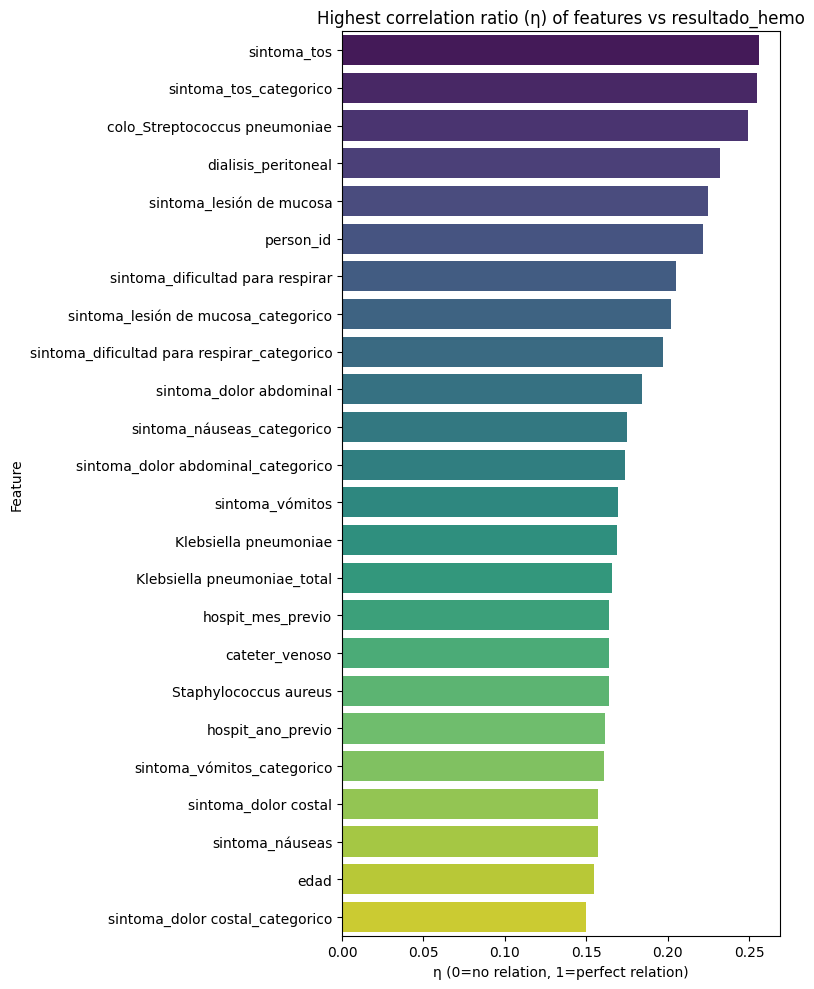

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

def correlation_ratio(categories, measurements):
    """Correlation ratio (eta squared) between categorical target and numerical feature"""
    categories = np.array(categories)
    measurements = np.array(measurements)
    cat_groups = [measurements[categories == cat] for cat in np.unique(categories)]
    means = [np.mean(g) for g in cat_groups if len(g) > 0]
    n = len(measurements)
    grand_mean = np.mean(measurements)
    ss_between = sum(len(g) * (m - grand_mean) ** 2 for g, m in zip(cat_groups, means))
    ss_total = sum((measurements - grand_mean) ** 2)
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else 0

target = "resultado_hemo"
df_expanded = df_expanded.rename(columns=sintom_map)
df = copy.deepcopy(df_expanded.drop(columns=["freq_bacteria", "freq_bac_foco"]))
le = LabelEncoder()
y = le.fit_transform(df[target])

corrs = {}
for col in df.select_dtypes(include=["number"]).columns:
    if col == target:
        continue
    corrs[col] = correlation_ratio(y, df[col].values)

corr_series = pd.Series({k:v for k,v in corrs.items() if v>0.15 and k!="weight"}).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=corr_series.values, y=corr_series.index, palette="viridis")
plt.title(f"Highest correlation ratio (η) of features vs {target}")
plt.xlabel("η (0=no relation, 1=perfect relation)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

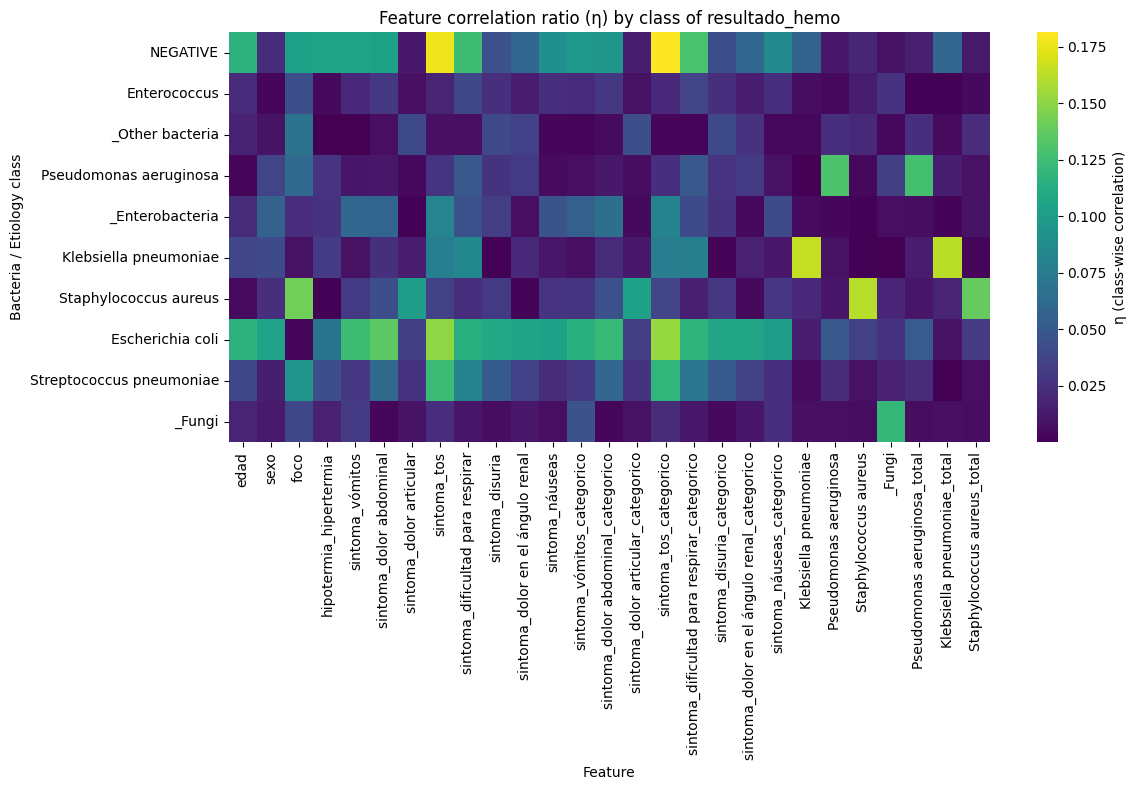

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
import copy

def correlation_ratio(categories, measurements):
    """Correlation ratio (eta squared) between categorical target and numerical feature"""
    categories = np.array(categories)
    measurements = np.array(measurements)
    cat_groups = [measurements[categories == cat] for cat in np.unique(categories)]
    means = [np.mean(g) for g in cat_groups if len(g) > 0]
    n = len(measurements)
    grand_mean = np.mean(measurements)
    ss_between = sum(len(g) * (m - grand_mean) ** 2 for g, m in zip(cat_groups, means))
    ss_total = sum((measurements - grand_mean) ** 2)
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else 0

# -------------------------------------
target = "resultado_hemo"
df_expanded = df_expanded.rename(columns=sintom_map)
df = copy.deepcopy(df_expanded.drop(columns=["person_id", "freq_bacteria", "freq_bac_foco"]))

# Get categories directly
classes = df[target].unique()
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target]

# Prepare a dataframe to store correlations per class and feature
corr_matrix = pd.DataFrame(index=classes, columns=numeric_cols, dtype=float)

for cls in classes:
    # binary target: this class vs the rest
    y_binary = (df[target] == cls).astype(int)
    for col in numeric_cols:
        corr_matrix.loc[cls, col] = correlation_ratio(y_binary, df[col].values)

# Optional: filter weak correlations
filtered = corr_matrix.loc[:, corr_matrix.max(axis=0) > 0.1]

# -------------------------------------
# 🔹 Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(filtered, annot=False, cmap="viridis", cbar_kws={"label": "η (class-wise correlation)"})
plt.title(f"Feature correlation ratio (η) by class of {target}")
plt.xlabel("Feature")
plt.ylabel("Bacteria / Etiology class")
plt.tight_layout()
plt.show()


## Subset for etiology modelling

Create a reduced dataframe focused on pre-admission events (infections, colonisations) paired with hemoculture outcomes.

In [28]:
df_hemo_merged = pd.merge(df_pacientes, hemo_urg_pivoted[["person_id", "resultado_hemo"]], on= ['person_id'], how= 'left')

orig_cols = df_hemo_merged.columns.tolist()
df_hemo_merged = df_hemo_merged.merge(tbl_infecciones_complete, on= ['person_id'], how= 'left')
df_hemo_merged = df_hemo_merged.merge(colo_prev_pivoted, on = ['person_id'], how= 'left')
new_cols = [c for c in df_hemo_merged.columns if c not in orig_cols]
df_hemo_merged[new_cols] = df_hemo_merged[new_cols].fillna(0) # Not all patients have previous infections/colonizations

df_hemo_merged = df_hemo_merged.merge(tbl_sepsis, on= ['person_id', 'fecha_ingreso_urgencias'], how= 'left')

In [30]:
df_expanded = df_hemo_merged.explode("resultado_hemo").reset_index(drop=True)
counts = df_expanded["person_id"].value_counts()
df_expanded["weight"] = df_expanded["person_id"].apply(lambda x: 1 / counts[x])
df_expanded["co_infection"] = np.where(df_expanded["weight"] < 1, 1, 0)

In [31]:
df_expanded.to_csv(os.path.join(save_location, "df_hemo_merged_v2.csv"), index=False)

## Additional feature refinements

Tidy remaining categorical columns and consolidate symptom encodings for downstream use.

In [98]:
#df_merged["numero_visitas"] = df_merged["numero_visitas"].fillna(0)
df_merged["mujer_gestante"] = df_merged["mujer_gestante"].replace("False", 0.0).astype(int)
# Process columns related with qsofa
qsofa_components = ["taquipnea", "estado_mental_alterado", "hipotension"]
df_merged["qsofa"] = df_merged["qsofa"].where(df_merged[qsofa_components].notna().all(axis=1), np.nan)

In [99]:
recode_dictlist = [{'value': '1', 'name': ' fiebre'},
 {'value': '2', 'name': ' tos'},
 {'value': '3', 'name': ' dificultad para respirar'},
 {'value': '4', 'name': ' dolor costal'},
 {'value': '5', 'name': ' disuria'},
 {'value': '6', 'name': ' síndrome de disuria - polaquiuria'},
 {'value': '7', 'name': ' tenesmo de ano y/o recto'},
 {'value': '8', 'name': ' dolor en el ángulo renal'},
 {'value': '9', 'name': ' náuseas'},
 {'value': '10', 'name': ' vómitos'},
 {'value': '11', 'name': ' dolor abdominal'},
 {'value': '12', 'name': ' diarrea'},
 {'value': '13', 'name': ' lesión de la piel'},
 {'value': '14', 'name': ' lesión de mucosa'},
 {'value': '15', 'name': ' cefalea'},
 {'value': '16', 'name': ' dolor articular'},
 ]
recode_dict = {d["value"]: d["name"].strip().replace(" ", "_") for d in recode_dictlist}
df_merged = df_merged.drop(["sintoma_nan", "sintoma_nan_categorico"], axis=1)
df_merged = df_merged.rename(columns={
    f"sintoma_{key}.0": f"sintoma_{val}" for key, val in recode_dict.items()
})
df_merged = df_merged.rename(columns={
    f"sintoma_{key}.0_categorico": f"sintoma_{val}_categorico" for key, val in recode_dict.items()
})

In [103]:
df_merged.to_csv(os.path.join(save_location, "processed_df.csv"), index=False)

## Generate automated EDA report

Reload the merged dataset and render an HTML profiling report with `ydata_profiling`.

In [ ]:
df_merged = pd.read_csv(os.path.join(save_location, "df_merged.csv"))

In [ ]:
profile = ProfileReport(df_merged, title="MePRAM EDA report")
profile.to_notebook_iframe()
profile.to_file(os.path.join(save_location, "df_merge_report.html"))

## Visualise missingness patterns

Plot heatmaps that highlight columns with substantial fractions of missing data to guide imputation strategies.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def insert_linebreak(string, lengLabel=10):
    return '\n'.join(string[i:i+lengLabel] for i in range(0, len(string), lengLabel))
merged_df = pd.read_csv(os.path.join(save_location, "df_merged.csv"))
prev_num = 0

def plot_missing_columns(subset_df, title=f"Missing Data Matrix for columns 0 to 171"):
    missing_df = subset_df.isna()

    missing_df.columns = subset_df.columns
    missing_percent = missing_df.mean() * 100
    columns_with_percent = [
        f"$\\bf{{{col}}}$ ({missing_percent[col]:.2f}%)" if missing_percent[col] > 30 else f"{col} ({missing_percent[col]:.2f}%)"
        for col in subset_df.columns
    ]
    plt.figure(figsize=(24, 6))
    ax = sns.heatmap(missing_df, vmin=0, vmax=1, cbar=False,
                xticklabels=columns_with_percent)
    ax.tick_params(axis='x', which='minor', length=40)
    plt.title(title)
    plt.xlabel("Columns (% Missing)")
    plt.ylabel("Rows", rotation=90)
    plt.xticks(rotation=90)
    plt.show()


plot_missing_columns(merged_df)

missing_df = merged_df.isna()
missing_df.columns = merged_df.columns
missing_percent = missing_df.mean() * 100
print([idx for idx,x in enumerate(missing_percent) if x > 30])
dangerous_df = merged_df.iloc[:, [idx for idx,x in enumerate(missing_percent) if x > 30]]
print(dangerous_df)
plot_missing_columns(dangerous_df, f"Missing Data Matrix of {len(dangerous_df.columns)} columns with > 30% NAs")

## Principal component analysis for feature exploration

Scale features with `MinMaxScaler`, fit 2D/3D PCA components, and visualise them interactively.

In [ ]:
TARGET_VARIABLE = "sepsis"

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

target = df_merged[TARGET_VARIABLE]
data = df_merged.drop(columns= [TARGET_VARIABLE])

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

explained_variance = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente: {explained_variance}")
print(f"Varianza total explicada: {sum(explained_variance)}")

plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=target, cmap='viridis', alpha=0.7)
plt.title("PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()


In [ ]:
import plotly.express as px 

pca_3d = PCA(n_components=3)
pca_data_3d = pca_3d.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data_3d, columns=["PC1", "PC2" ,"PC3"])
pca_df[TARGET_VARIABLE] = target

fig = px.scatter_3d(
    pca_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color = TARGET_VARIABLE,
    title = "PCA - 3D Visualization",
    labels= {TARGET_VARIABLE},
    color_continuous_scale="Viridis", 
    opacity=0.7  
)
fig.update_traces(marker=dict(size=5))  
fig.update_layout(scene=dict(
    xaxis_title="PC 1",
    yaxis_title="PC 2",
    zaxis_title="PC 3"
))
fig.show()

In [53]:
dataframes.keys()

dict_keys(['tbl_master', 'tbl_paciente', 'tbl_comorbilidad', 'tbl_factores_riesgo_bmr', 'tbl_sintomas', 'tbl_signos', 'tbl_sepsis', 'tbl_infecciones_previas', 'tbl_colonizaciones_previas', 'tbl_tratamiento_antibiotico_previo', 'tbl_tratamiento_empirico', 'tbl_hemocultivo_de_urgencias', 'tbl_otros_cultivos_en_urgencias', 'tbl_codes2names', 'tbl_personid2center', 'tbl_microorganismos'])

In [ ]:
processed_df_copy = df_merged

target_copy = processed_df_copy[TARGET_VARIABLE]
scaler = MinMaxScaler()
X_preprocessed = pd.DataFrame(scaler.fit_transform(processed_df_copy.drop(columns=[TARGET_VARIABLE])))
X_preprocessed[TARGET_VARIABLE] = target_copy

target_palette = {0: "blue", 1: "red"}
row_colors = X_preprocessed[TARGET_VARIABLE].map(target_palette)
X_preprocessed = X_preprocessed.dropna() 
sns.clustermap(
    X_preprocessed.drop(columns=[TARGET_VARIABLE]), 
    cmap="coolwarm",
    row_colors=row_colors,
    figsize=(30, 60),
    annot=False,
    col_cluster=False
)

plt.title("Heatmap con Clustering y Anotación por Target", pad=100)
plt.show()

## Correlation pair plots for symptoms and signs

Build Seaborn PairGrids to inspect relationships among symptom/sign variables and the sepsis label.

In [ ]:
sintomas_columns = [col for col in sintom_sign_sepsis.columns if "sintoma" in col]
binary_columns = [col for col in sintom_sign_sepsis.columns if sintom_sign_sepsis[col].dropna().value_counts().index.isin([0, 1]).all() and col not in sintomas_columns]
numeric_columns = [col for col in sintom_sign_sepsis.columns if sintom_sign_sepsis[col].dtype in ['int64', 'float64'] and col not in binary_columns and col not in sintomas_columns]
print(binary_columns)
print(numeric_columns)
print(sintomas_columns)

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pg = sns.PairGrid(sintom_sign_sepsis[binary_columns], hue="sepsis", palette="Set2")
pg.map_diag(sns.histplot)
pg.map_offdiag(sns.barplot)
pg.add_legend()
plt.show()

In [ ]:
sintomas_columns_group1 = sintomas_columns[0:int(len(sintomas_columns)/2)]
sintomas_columns_group1 = list(set(sintomas_columns_group1 + ["sepsis"]))
sns.color_palette("tab10")
pg = sns.PairGrid(sintom_sign_sepsis[sintomas_columns_group1], hue="sepsis", palette="Set2")
pg.map_diag(sns.histplot)
pg.map_offdiag(sns.scatterplot, alpha=0.6)
pg.add_legend()
plt.show()

In [ ]:
sintomas_columns_group2 = sintomas_columns[int(len(sintomas_columns)/2):-1]
sintomas_columns_group2 = list(set(sintomas_columns_group2 + ["sepsis"]))
pg = sns.PairGrid(sintom_sign_sepsis[sintomas_columns_group2], hue="sepsis", palette="Set2")
pg.map_diag(sns.histplot, alpha=0.5)
pg.map_offdiag(sns.scatterplot, alpha=0.6)
pg.add_legend()
plt.show()

In [ ]:
numeric_columns = list(set(numeric_columns + ["sepsis"]))
pg = sns.PairGrid(sintom_sign_sepsis[numeric_columns].drop("person_id", axis=1), hue="sepsis", palette="Set2")
pg.map_diag(sns.kdeplot, alpha=0.8)
pg.map_offdiag(sns.scatterplot, alpha=0.6)
pg.add_legend()
sns.color_palette("tab10")
plt.show()